# Примеры использования утилиты FlowMapUtilite
В данном тетради будут приведены примеры использования данной утилиты


## Пример №1 — Вертикальная труба, модель Ансари (автовыбор)

Диаметр трубы: 62 мм

Абсолютная шероховатость: 0.1 мм

Угол наклона трубы: 90°

Плотность жидкости: 800 $\text{кг /}\text{м}^{3}$

Плотность газа: 50 $\text{кг /}\text{м}^{3}$

Вязкость жидкости: 1 сПз

Вязкость газа: 0.01 сПз

Поверхностное натяжение на границе жидкость - газ: 0.01 Н/м

Название модели корреляции: Ансари (выбирается автоматически для угла 75°-90°)

Размер матрицы (количество точек на оси): 100


[[105 105 105 ... 105 105 105]
 [105 105 105 ... 105 105 105]
 [105 105 105 ... 105 105 105]
 ...
 [103 103 103 ... 102 102 102]
 [103 103 103 ... 102 102 102]
 [103 103 103 ... 102 102 102]]


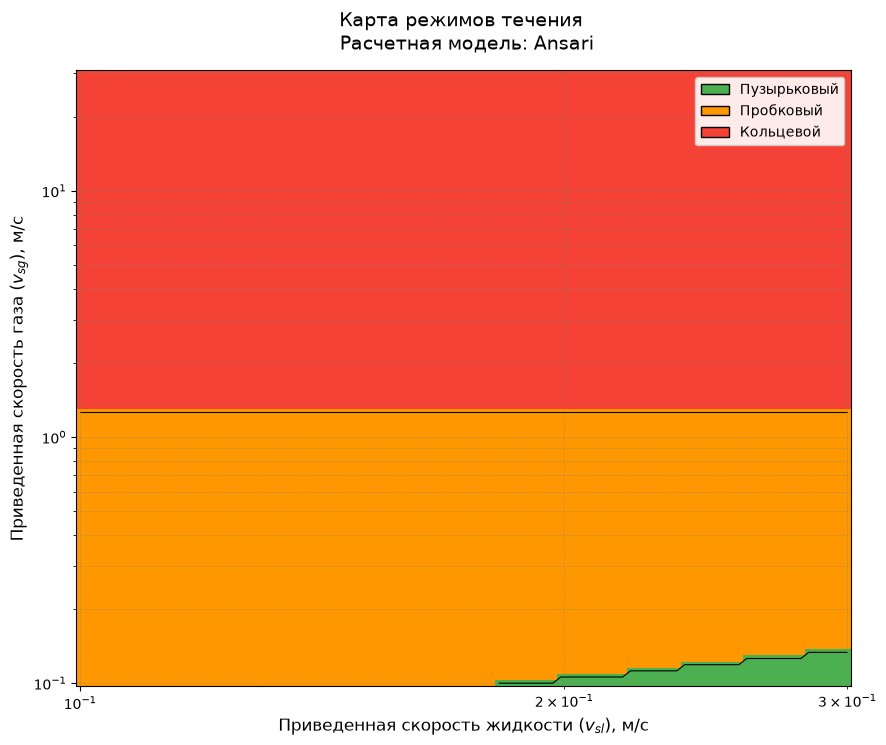

In [1]:
%matplotlib inline
from flowmaputility.builder import Builder


def main() -> None:
    obj = (
        Builder()
        .set_pipe_params(pipe_diameter_m, roughness_m, angle_deg)
        .set_fluid_params(rho_liq_si, rho_gas_si, mu_liq_si, mu_gas_si, sigma_si)
        .set_velocite_gas(0.1, 30)
        .set_velocite_liquid(0.1, 0.3)
        .set_resolution(100)
    )

    obj.build_all().run()


if __name__ == "__main__":
    pipe_diameter_m = 0.062
    roughness_m = 0.0001
    angle_deg = 90.0

    rho_liq_si = 800.0
    rho_gas_si = 50.0
    mu_liq_si = 1.0 * 0.001
    mu_gas_si = 0.01 * 0.001
    sigma_si = 0.01
    main()


## Пример №2 — Наклонная труба, модель Beggs-Brill (автовыбор)

Тот же флюид и труба, только угол наклона другой — фабрика моделей сама подберёт подходящую корреляцию.

Диаметр трубы: 62 мм

Абсолютная шероховатость: 0.1 мм

Угол наклона трубы: 30°

Плотность жидкости: 800 $\text{кг /}\text{м}^{3}$

Плотность газа: 50 $\text{кг /}\text{м}^{3}$

Вязкость жидкости: 1 сПз

Вязкость газа: 0.01 сПз

Поверхностное натяжение на границе жидкость - газ: 0.01 Н/м

Название модели корреляции: Беггс-Брилл (выбирается автоматически для угла 0°-75°, не включая 75°)

Размер матрицы (количество точек на оси): 100


[[104 104 104 ... 104 104 104]
 [104 104 104 ... 104 104 104]
 [104 104 104 ... 104 104 104]
 ...
 [103 103 103 ... 103 103 103]
 [103 103 103 ... 103 103 103]
 [103 103 103 ... 103 103 103]]


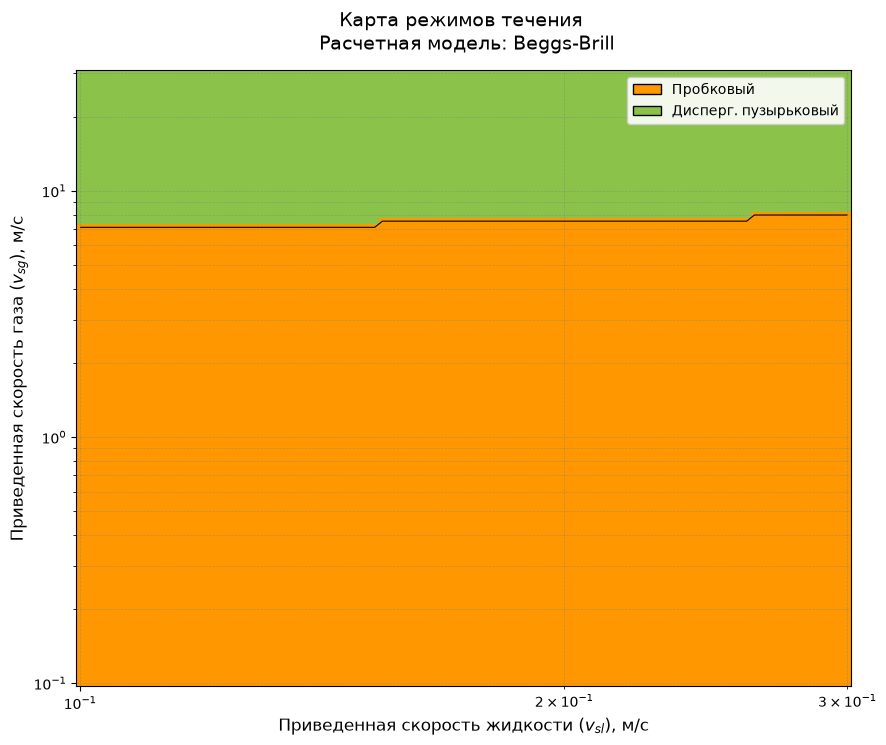

In [2]:
from flowmaputility.builder import Builder


def main() -> None:
    obj = (
        Builder()
        .set_pipe_params(pipe_diameter_m, roughness_m, angle_deg)
        .set_fluid_params(rho_liq_si, rho_gas_si, mu_liq_si, mu_gas_si, sigma_si)
        .set_velocite_gas(0.1, 30)
        .set_velocite_liquid(0.1, 0.3)
        .set_resolution(100)
    )

    obj.build_all().run()


if __name__ == "__main__":
    pipe_diameter_m = 0.062
    roughness_m = 0.0001
    angle_deg = 30.0

    rho_liq_si = 800.0
    rho_gas_si = 50.0
    mu_liq_si = 1.0 * 0.001
    mu_gas_si = 0.01 * 0.001
    sigma_si = 0.01
    main()


## Пример №3 — Явный выбор модели по имени (set_model)

Обычно модель выбирается автоматически по углу трубы, но её можно указать явно через `set_model(...)`. Имя регистронезависимо, дефис и пробел равнозначны подчёркиванию: `"Beggs-Brill"`, `"beggs_brill"` и `"BEGGS BRILL"` — это одно и то же имя модели.

Диаметр трубы: 62 мм

Абсолютная шероховатость: 0.1 мм

Угол наклона трубы: 45°

Флюид — такой же, как в примерах выше

Название модели корреляции: явно указана `Beggs-Brill`

Размер матрицы (количество точек на оси): 100


[[104 104 104 ... 104 104 104]
 [104 104 104 ... 104 104 104]
 [104 104 104 ... 104 104 104]
 ...
 [103 103 103 ... 103 103 103]
 [103 103 103 ... 103 103 103]
 [103 103 103 ... 103 103 103]]


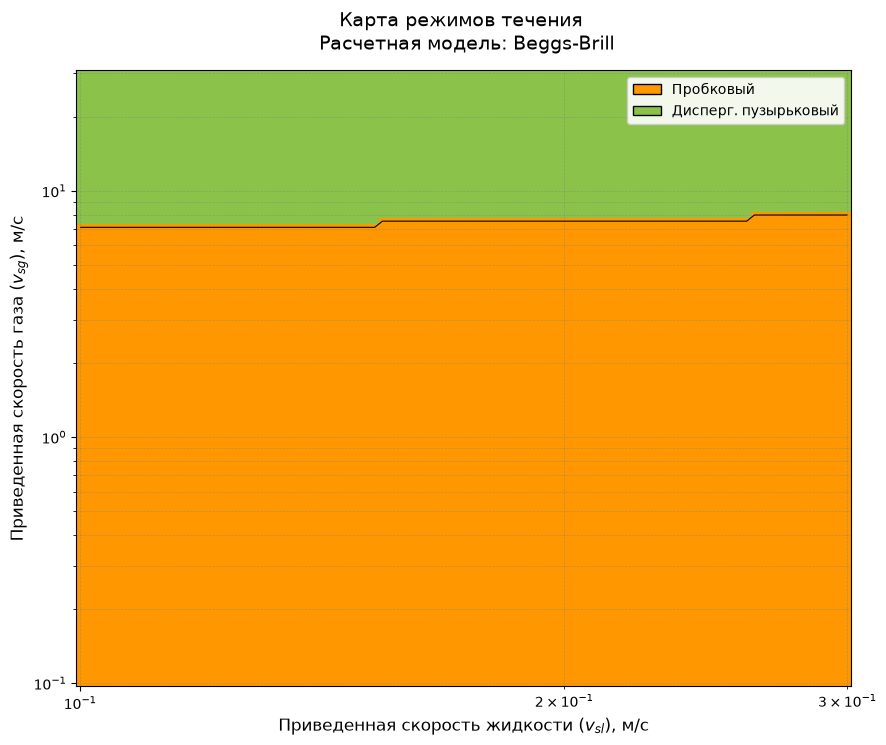

In [3]:
from flowmaputility.builder import Builder


def main() -> None:
    obj = (
        Builder()
        .set_pipe_params(0.062, 0.0001, 45.0)
        .set_fluid_params(800.0, 50.0, 1.0 * 0.001, 0.01 * 0.001, 0.01)
        .set_velocite_liquid(0.1, 0.3)
        .set_velocite_gas(0.1, 30)
        .set_resolution(100)
        .set_model("Beggs-Brill")
    )

    obj.build_all().run()


if __name__ == "__main__":
    main()


## Пример №4 — Прогресс-бар расчёта (set_show_progress)

По умолчанию прогресс-бар выключен. Включается через `set_show_progress(True)`. Сетка увеличена до 200×200, чтобы прогресс успел отрисоваться.

Диаметр трубы: 62 мм

Абсолютная шероховатость: 0.1 мм

Угол наклона трубы: 90° (модель Ансари, автовыбор)

Флюид — такой же, как в примерах выше

Размер матрицы (количество точек на оси): 200


Расчёт карты режимов:   0%|          | 0/200 [00:00<?, ?it/s]

Расчёт карты режимов:  17%|█▋        | 34/200 [00:00<00:00, 321.29it/s]

Расчёт карты режимов:  34%|███▎      | 67/200 [00:00<00:00, 301.09it/s]

Расчёт карты режимов:  52%|█████▏    | 103/200 [00:00<00:00, 324.57it/s]

Расчёт карты режимов:  68%|██████▊   | 136/200 [00:00<00:00, 318.07it/s]

Расчёт карты режимов:  84%|████████▍ | 168/200 [00:00<00:00, 246.66it/s]

Расчёт карты режимов:  98%|█████████▊| 197/200 [00:00<00:00, 252.47it/s]

Расчёт карты режимов: 100%|██████████| 200/200 [00:00<00:00, 273.89it/s]

[[105 105 105 ... 105 105 105]
 [105 105 105 ... 105 105 105]
 [105 105 105 ... 105 105 105]
 ...
 [103 103 103 ... 102 102 102]
 [103 103 103 ... 102 102 102]
 [103 103 103 ... 102 102 102]]


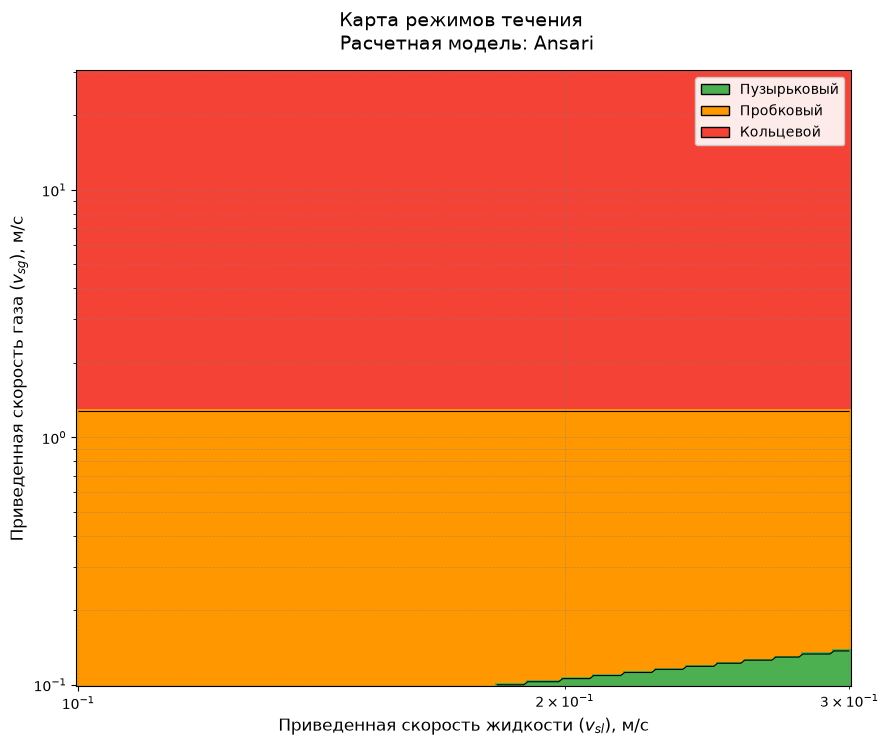

In [4]:
from flowmaputility.builder import Builder


def main() -> None:
    obj = (
        Builder()
        .set_pipe_params(0.062, 0.0001, 90.0)
        .set_fluid_params(800.0, 50.0, 1.0 * 0.001, 0.01 * 0.001, 0.01)
        .set_velocite_liquid(0.1, 0.3)
        .set_velocite_gas(0.1, 30)
        .set_resolution(200)
        .set_show_progress(True)
    )

    obj.build_all().run()


if __name__ == "__main__":
    main()
